In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt

In [82]:
class Binarize(object):
    def __call__(self, t):
        return (t > 0).float()

In [83]:
mnist_dataset = MNIST('./data', True, transform=transforms.Compose([
    transforms.RandomAffine(15, (0.2, 0.2)),
    transforms.ToTensor(),
    Binarize()

]), download=True)
mnist_dataloader = DataLoader(mnist_dataset, 64, True)

torch.Size([1, 28, 28])
(tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
          1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
          1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
          1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0.

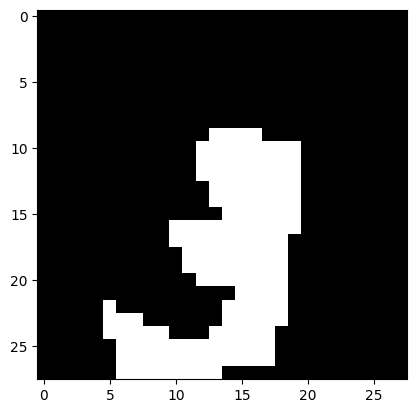

In [84]:
print(mnist_dataset[0][0].shape)
plt.imshow(mnist_dataset[10][0].permute(1,2,0), cmap='gray')
print(mnist_dataset[0])

In [85]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.ReLU(),

    nn.Linear(256, 128),
    nn.ReLU(),

    nn.Linear(128, 32),
    nn.ReLU(),

    nn.Linear(32, 10),
    nn.ReLU(),
)

In [87]:
optimizer = optim.Adam(model.parameters(), 0.0001)
criterion = nn.CrossEntropyLoss()
epochs = 1000

losses = []

for epoch in range(epochs):
    avg_loss = 0
    for x, y in mnist_dataloader:
        y_pred = model(x)
        loss = criterion(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        avg_loss += loss.item()
    
    avg_loss /= len(mnist_dataloader)
    print(f'Epoch {epoch}, avg_loss {avg_loss}') #1.33m -> 0.733

Epoch 0, avg_loss 0.7775481941857572
Epoch 1, avg_loss 0.7686581198594717
Epoch 2, avg_loss 0.7664259699489008


KeyboardInterrupt: 

In [90]:
import json

def export_model_to_json(model, file_path):
    data = []
    for layer in model:
        if isinstance(layer, torch.nn.Linear):
            weights = layer.weight.detach().numpy().tolist()
            biases = layer.bias.detach().numpy().tolist()
            data.append({"weights": weights, "biases": biases})
    
    with open(file_path, "w") as f:
        json.dump(data, f)

export_model_to_json(model, "model_params.json")

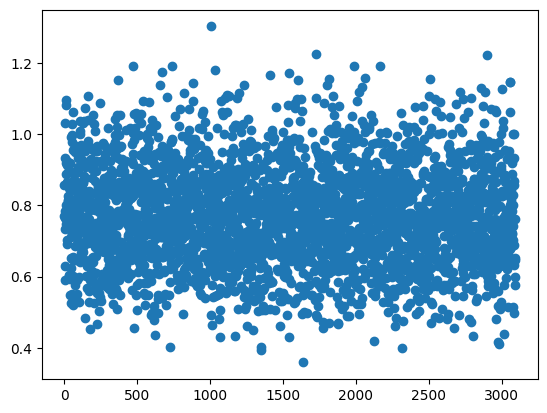

In [88]:
plt.plot(range(len(losses)), losses, 'o')